# Algorithme de Grover Biaisé : DEGGA avec État Initial Non-Uniforme

**Projet de recherche étudiant — Informatique Quantique**

---

## Objectif

Ce notebook implémente l'algorithme **DEGGA biaisé** : une version améliorée de la recherche quantique de Grover qui exploite une **connaissance a priori** sur la solution pour réduire le nombre d'itérations.

### Les trois algorithmes couverts

| Algorithme | État initial | Phase | P(succès) | Itérations |
|-----------|-------------|-------|-----------|------------|
| Grover standard | Uniforme H⊗n\|0⟩ | φ = π | ≈ 1 (pas exact) | T ≈ π/(4β) |
| DEGGA / Long | Uniforme H⊗n\|0⟩ | φ optimal | **= 1 (exact)** | T identique |
| **DEGGA biaisé** | **Non-uniforme A\|0⟩** | φ optimal | **= 1 (exact)** | **T réduit** |

---

## Rappel : Algorithme de Grover Standard

On cherche un état cible |τ⟩ parmi N = 2ⁿ états. L'algorithme applique T fois :

**G = D · O** où :
- **Oracle O** : applique -1 (phase π) sur l'état cible
- **Diffusion D** = H⊗n · R₀(π) · H⊗n : amplifie les amplitudes

Probabilité après T itérations : **P(T) = sin²((2T+1)·β)** avec β = arcsin(1/√N)

---

## Algorithme de Long (2001) — Base de DEGGA

Long généralise Grover en utilisant une phase φ ≠ π sur l'oracle ET la diffusion.
La **condition de correspondance de phase** garantit P = 100% :

$$\varphi = 2 \arcsin\!\left(\frac{\sin(\pi/(4T+2))}{\sin(\beta)}\right)$$

Probabilité exacte : **P(T) = sin²((2T+1) · arcsin(sin(β)·sin(φ/2))) = 1**

---

## DEGGA Biaisé — Innovation

Si l'on dispose d'informations a priori, on prépare un état initial non-uniforme **|ψ⟩ = A|0⟩**.

**Adaptation de la diffusion** : remplacer H⊗n par A
$$D_A(\varphi) = A \cdot R_0(\varphi) \cdot A^\dagger$$

**Nouveau paramètre β** : si l'amplitude de |τ⟩ dans |ψ⟩ est α_τ = √p_τ, alors
$$\beta_{\text{biaisé}} = \arcsin(\alpha_\tau) = \arcsin(\sqrt{p_\tau}) > \beta_{\text{uniforme}}$$

**Conséquence** : β plus grand → T plus petit → **moins d'itérations !**

---

## Prérequis

```bash
pip install qiskit qiskit-aer numpy matplotlib
```
Versions testées : `qiskit >= 1.0`, `qiskit-aer >= 0.14`

In [1]:
# =============================================================
# CELLULE 1 : IMPORTATION DES BIBLIOTHÈQUES
# =============================================================

# Calcul numérique (vecteurs, matrices, fonctions mathématiques)
import numpy as np

# Visualisation graphique
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Qiskit — Framework de calcul quantique IBM
from qiskit import QuantumCircuit, ClassicalRegister, transpile

# StatePreparation : prépare un état quantique arbitraire à partir de |0⟩
# PhaseGate       : porte de phase P(φ)|1⟩ = e^(iφ)|1⟩
from qiskit.circuit.library import StatePreparation, PhaseGate

# Statevector : simulation exacte du vecteur d'état (sans bruit)
from qiskit.quantum_info import Statevector

# AerSimulator : simulateur de circuits quantiques
from qiskit_aer import AerSimulator

# Configuration de l'affichage des graphiques
%matplotlib inline
plt.rcParams.update({
    'figure.figsize': [14, 5],
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3
})

import qiskit
print(f"Qiskit version : {qiskit.__version__}")
print("Toutes les bibliothèques importées avec succès.")

Qiskit version : 2.4.1
Toutes les bibliothèques importées avec succès.


In [2]:
# =============================================================
# CELLULE 2 : FONCTIONS UTILITAIRES
# =============================================================

# ------------------------------------------------------------------
# ORACLE GÉNÉRALISÉ
# Applique la phase e^(iφ) à l'état cible |cible⟩.
#
# Grover standard → φ = π  (inversion de phase : -1)
# Long / DEGGA    → φ calculé pour succès exact à 100%
#
# Implémentation en 3 étapes :
#  1. Retourner les qubits à '0' de |cible⟩  →  amène |cible⟩ vers |11...1⟩
#  2. Phase multi-contrôlée sur |11...1⟩
#  3. Restaurer les qubits (opération symétrique)
#
# Convention Qiskit : qubit 0 = bit de poids faible (LSB)
#   Exemple : cible = 5 = |101⟩  →  qubit0=1, qubit1=0, qubit2=1
# ------------------------------------------------------------------
def creer_oracle(n_qubits, cible, phi):
    qc = QuantumCircuit(n_qubits, name=f'Oracle φ={phi:.2f}')

    # Représentation binaire de la cible (LSB en premier via reversed)
    bits = format(cible, f'0{n_qubits}b')

    # Étape 1 : X sur les qubits dont le bit cible est '0'
    for i, bit in enumerate(reversed(bits)):
        if bit == '0':
            qc.x(i)

    # Étape 2 : phase e^(iφ) quand tous les qubits sont |1⟩
    # PhaseGate(φ).control(k) = phase contrôlée par k qubits
    if n_qubits == 1:
        qc.p(phi, 0)
    else:
        qc.append(PhaseGate(phi).control(n_qubits - 1), list(range(n_qubits)))

    # Étape 3 : restauration (identique à l'étape 1, X est auto-inverse)
    for i, bit in enumerate(reversed(bits)):
        if bit == '0':
            qc.x(i)

    return qc


# ------------------------------------------------------------------
# PHASE SUR L'ÉTAT ZÉRO
# Applique e^(iφ) à |00...0⟩.
# Brique de base de l'opérateur de diffusion.
# Même technique que l'oracle : retourner TOUS les qubits pour
# amener |0...0⟩ à |1...1⟩, appliquer la phase, puis restaurer.
# ------------------------------------------------------------------
def creer_phase_zero(n_qubits, phi):
    qc = QuantumCircuit(n_qubits, name='R₀(φ)')
    qc.x(range(n_qubits))                                             # |0...0⟩ → |1...1⟩
    if n_qubits == 1:
        qc.p(phi, 0)
    else:
        qc.append(PhaseGate(phi).control(n_qubits - 1), list(range(n_qubits)))
    qc.x(range(n_qubits))                                             # |1...1⟩ → |0...0⟩
    return qc


# ------------------------------------------------------------------
# PARAMÈTRES DE L'ALGORITHME DE LONG / DEGGA
#
# Condition de correspondance de phase :
#   φ = 2 · arcsin( sin(π/(4T+2)) / sin(β) )
#
# Cette formule garantit P(T) = sin²((2T+1)·arcsin(sin(β)·sin(φ/2))) = 1
# car sin(β)·sin(φ/2) = sin(π/(4T+2))
# donc (2T+1)·arcsin(...) = (2T+1)·π/(4T+2) = π/2 → sin²(π/2) = 1
# ------------------------------------------------------------------
def parametres_long(beta):
    """
    Calcule T (iterations) et φ (phase) pour l'algorithme exact de Long/DEGGA.

    Paramètre
    ---------
    beta : float — angle tel que sin(β) = amplitude de |cible⟩ dans |ψ_initial⟩

    Retourne
    --------
    T   : int   — nombre minimum d'itérations (garantit P=100%)
    phi : float — angle de phase en radians
    """
    # T minimum tel que sin(π/(4T+2)) ≤ sin(β), i.e. π/(4T+2) ≤ β
    # Condition : T ≥ π/(4β) - 1/2
    T = max(1, int(np.ceil(np.pi / (4.0 * beta) - 0.5)))

    # Angle de phase (phase-matching condition)
    arg = np.sin(np.pi / (4 * T + 2)) / np.sin(beta)
    phi = 2.0 * np.arcsin(np.clip(arg, -1.0, 1.0))  # clip pour robustesse numérique

    return T, phi


# ------------------------------------------------------------------
# PROBABILITÉ THÉORIQUE DE SUCCÈS
#
# Après j itérations avec phase φ :
#   P(j) = sin²( (2j+1) · arcsin(sin(β) · sin(φ/2)) )
#
# Cas particuliers :
#   φ = π (Grover standard)   → P(j) = sin²((2j+1)·β)
#   φ = valeur Long, j = T    → P(T) = 1 exactement
# ------------------------------------------------------------------
def prob_theorique(beta, phi, j):
    theta_eff = np.arcsin(np.clip(np.sin(beta) * np.sin(phi / 2.0), -1.0, 1.0))
    return float(np.sin((2 * j + 1) * theta_eff) ** 2)


# ------------------------------------------------------------------
# OUTILS DE SIMULATION
# ------------------------------------------------------------------
def probs_exactes(circuit_sans_mesure):
    """Probabilités exactes via simulation du vecteur d'état (pas d'échantillonnage)."""
    sv = Statevector(circuit_sans_mesure)
    n = circuit_sans_mesure.num_qubits
    return {format(i, f'0{n}b'): float(p) for i, p in enumerate(sv.probabilities())}


def simuler_shots(circuit_avec_mesure, shots=4096):
    """Simulation réaliste avec shots répétitions (comme une vraie expérience)."""
    sim = AerSimulator()
    qc_compile = transpile(circuit_avec_mesure, sim, optimization_level=1)
    return sim.run(qc_compile, shots=shots).result().get_counts()


def afficher_barchart(ax, probs_dict, n_qubits, cible, titre, couleur='steelblue'):
    """Affiche un histogramme de probabilités, en rouge pour l'état cible."""
    N = 2 ** n_qubits
    etats = [format(i, f'0{n_qubits}b') for i in range(N)]
    vals = [probs_dict[e] for e in etats]
    cols = ['red' if i == cible else couleur for i in range(N)]
    ax.bar(etats, vals, color=cols, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('État quantique')
    ax.set_ylabel('Probabilité')
    ax.set_title(titre)
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels(etats, rotation=45)
    legende = [mpatches.Patch(color='red', label='État cible'),
               mpatches.Patch(color=couleur, label='Autres états')]
    ax.legend(handles=legende, fontsize=9)


print("Fonctions utilitaires définies :")
print("  creer_oracle, creer_phase_zero, parametres_long,")
print("  prob_theorique, probs_exactes, simuler_shots, afficher_barchart")

Fonctions utilitaires définies :
  creer_oracle, creer_phase_zero, parametres_long,
  prob_theorique, probs_exactes, simuler_shots, afficher_barchart


Espace de recherche : 8 états (|000⟩ à |111⟩)
État cible          : |101⟩ = 5

Grover standard (φ = π = inversion de phase) :
  β = arcsin(1/√8) = 0.3614 rad = 20.70°
  T = 2 itérations
  P théorique = sin²(5β) = 0.9453  ← pas exactement 1 !


/var/folders/yh/z2gz5vm57r79zh1zl2qvskp40000gq/T/ipykernel_85075/2767923254.py:141: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etats, rotation=45)


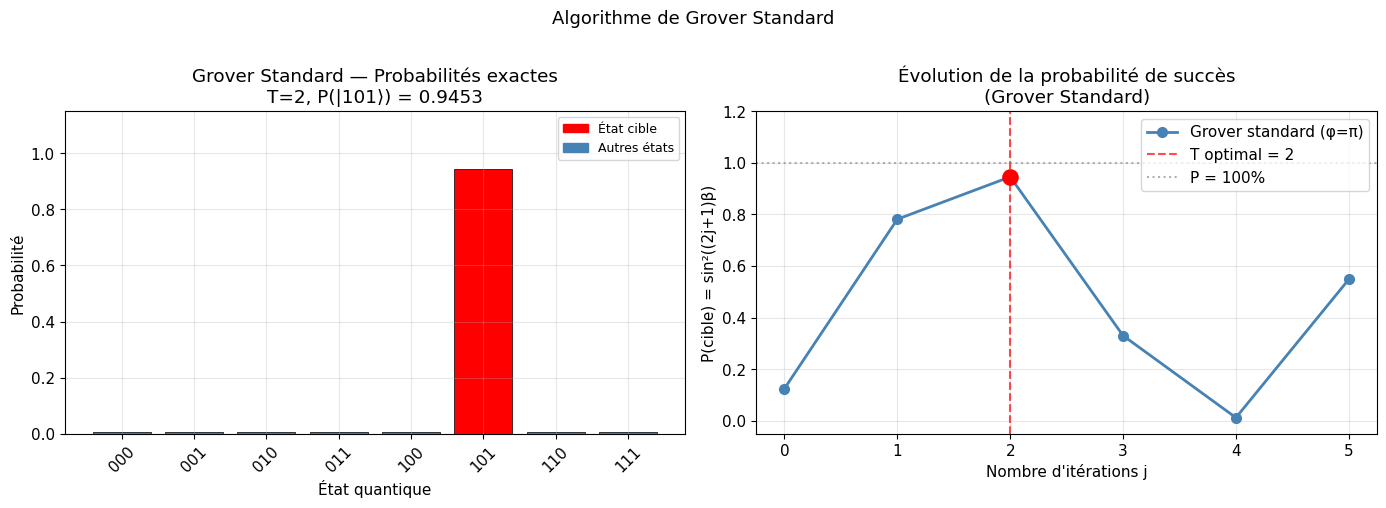


Simulation (4096 shots) : |101⟩ mesuré 3875 fois → fréquence = 0.946
Probabilité théorique : 0.9453


In [3]:
# =============================================================
# CELLULE 3 : ALGORITHME DE GROVER STANDARD
# =============================================================

# --- Paramètres de l'exemple (communs aux 3 algorithmes) ---
N_QUBITS = 3         # Espace de recherche : 2^3 = 8 états
CIBLE    = 5         # On cherche |101⟩ = 5 en décimal
N        = 2 ** N_QUBITS

print(f"Espace de recherche : {N} états (|000⟩ à |111⟩)")
print(f"État cible          : |{format(CIBLE, f'0{N_QUBITS}b')}⟩ = {CIBLE}")

# β uniforme : angle dans le sous-espace 2D {|cible⟩, |cible⊥⟩}
# sin(β) = amplitude de |cible⟩ dans la superposition uniforme = 1/√N
beta_unif = np.arcsin(1.0 / np.sqrt(N))

# Nombre d'itérations optimal pour Grover standard : T ≈ π/(4β) - 1/2
T_std = max(1, round(np.pi / (4 * beta_unif) - 0.5))
P_std = prob_theorique(beta_unif, np.pi, T_std)

print(f"\nGrover standard (φ = π = inversion de phase) :")
print(f"  β = arcsin(1/√{N}) = {beta_unif:.4f} rad = {np.degrees(beta_unif):.2f}°")
print(f"  T = {T_std} itérations")
print(f"  P théorique = sin²({2*T_std+1}β) = {P_std:.4f}  ← pas exactement 1 !")


# ------------------------------------------------------------------
# Construction du circuit de Grover standard
#
# Structure :
#   ┌───┐   ┌────────┐   ┌───┐   ┌──────┐   ┌───┐
#   │ H ├───┤ Oracle ├───┤ H ├───┤ R₀(π)├───┤ H ├─── mesure
#   └───┘   └────────┘   └───┘   └──────┘   └───┘
#  Init.     │← Oracle →│  │← Diffusion (H·R₀·H) →│
#            └──────────────────────────────────────┘
#                        ← 1 itération Grover →
# ------------------------------------------------------------------
def circuit_grover_std(n_qubits, cible, n_iter):
    qc = QuantumCircuit(n_qubits, name='Grover Standard')

    # Initialisation : superposition uniforme via portes Hadamard
    # H|0⟩ = (|0⟩+|1⟩)/√2 → sur n qubits : H⊗n|0⟩ = (1/√N)·Σ|i⟩
    qc.h(range(n_qubits))
    qc.barrier()

    for _ in range(n_iter):
        # Oracle : φ = π (inversion de phase sur l'état cible)
        qc.append(creer_oracle(n_qubits, cible, np.pi), range(n_qubits))

        # Diffusion standard : H · R₀(π) · H
        # Équivaut à 2|s⟩⟨s| - I (réflexion autour de l'état uniforme)
        qc.h(range(n_qubits))
        qc.append(creer_phase_zero(n_qubits, np.pi), range(n_qubits))
        qc.h(range(n_qubits))
        qc.barrier()

    return qc


# Circuit pour simulation exacte (sans mesures)
qc_std_sim = circuit_grover_std(N_QUBITS, CIBLE, T_std)
probs_std = probs_exactes(qc_std_sim)

# Circuit pour simulation par échantillonnage (avec mesures)
qc_std_meas = circuit_grover_std(N_QUBITS, CIBLE, T_std)
qc_std_meas.add_register(ClassicalRegister(N_QUBITS, 'c'))
qc_std_meas.measure(range(N_QUBITS), range(N_QUBITS))
counts_std = simuler_shots(qc_std_meas, shots=4096)

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des probabilités
afficher_barchart(
    axes[0], probs_std, N_QUBITS, CIBLE,
    f'Grover Standard — Probabilités exactes\n'
    f'T={T_std}, P(|{format(CIBLE,f"0{N_QUBITS}b")}⟩) = {probs_std[format(CIBLE,f"0{N_QUBITS}b")]:.4f}',
    'steelblue'
)

# Évolution de la probabilité d'itération en itération
iters = list(range(T_std + 4))
p_evo_std = [prob_theorique(beta_unif, np.pi, j) for j in iters]
axes[1].plot(iters, p_evo_std, 'o-', color='steelblue', linewidth=2, markersize=7,
             label='Grover standard (φ=π)')
axes[1].axvline(x=T_std, color='red', linestyle='--', alpha=0.7, label=f'T optimal = {T_std}')
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.6, label='P = 100%')
axes[1].scatter([T_std], [p_evo_std[T_std]], color='red', s=120, zorder=5)
axes[1].set_xlabel("Nombre d'itérations j")
axes[1].set_ylabel('P(cible) = sin²((2j+1)β)')
axes[1].set_title('Évolution de la probabilité de succès\n(Grover Standard)')
axes[1].set_ylim(-0.05, 1.2)
axes[1].legend()

plt.suptitle('Algorithme de Grover Standard', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Résultat des mesures
cle_cible = format(CIBLE, f'0{N_QUBITS}b')
total_shots = sum(counts_std.values())
freq = counts_std.get(cle_cible, 0) / total_shots
print(f"\nSimulation ({total_shots} shots) : |{cle_cible}⟩ mesuré {counts_std.get(cle_cible,0)} fois → fréquence = {freq:.3f}")
print(f"Probabilité théorique : {probs_std[cle_cible]:.4f}")

DEGGA / Algorithme de Long (état initial uniforme) :
  β        = 0.3614 rad = 20.70°
  T        = 2 itération(s)  (même que Grover standard)
  φ        = 2.1269 rad = 121.86°  ← différent de 180° !
  P(T)     = 1.00000000  ← exactement 1 !


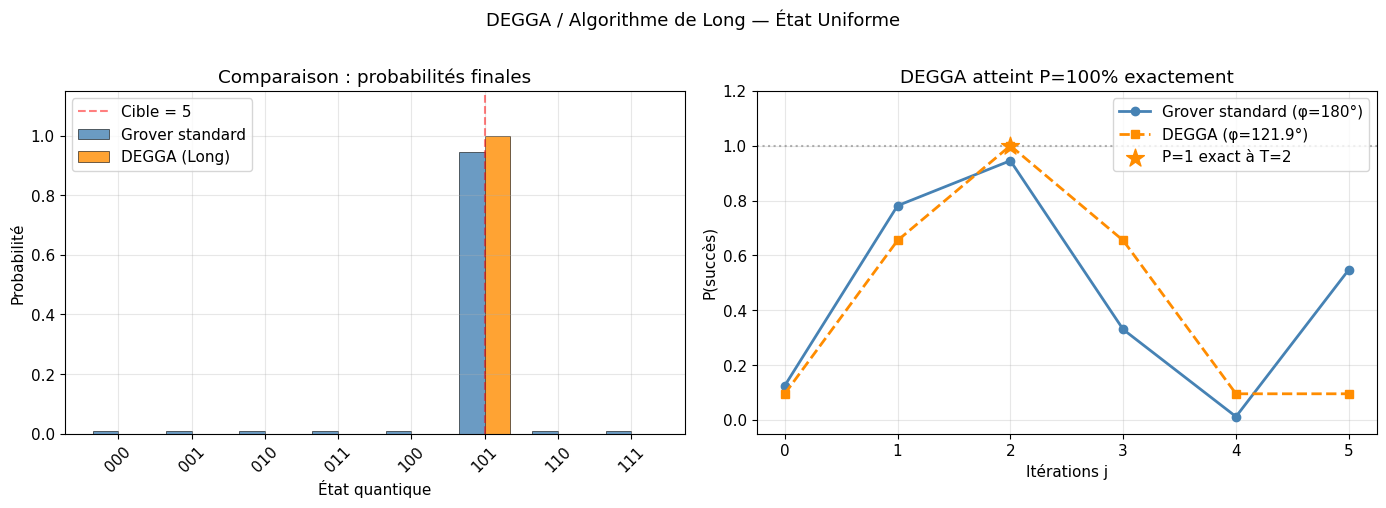


Simulation (4096 shots) : fréquence de |101⟩ = 1.000
Probabilité théorique   : 1.000000


In [4]:
# =============================================================
# CELLULE 4 : ALGORITHME DE LONG / DEGGA (ÉTAT UNIFORME)
# =============================================================
# Même structure que Grover mais avec φ ≠ π calculé par la
# condition de correspondance de phase. Résultat : P = 100%.
# =============================================================

# Calcul des paramètres optimaux
T_long, phi_long = parametres_long(beta_unif)
P_long = prob_theorique(beta_unif, phi_long, T_long)

print("DEGGA / Algorithme de Long (état initial uniforme) :")
print(f"  β        = {beta_unif:.4f} rad = {np.degrees(beta_unif):.2f}°")
print(f"  T        = {T_long} itération(s)  (même que Grover standard)")
print(f"  φ        = {phi_long:.4f} rad = {np.degrees(phi_long):.2f}°  ← différent de 180° !")
print(f"  P(T)     = {P_long:.8f}  ← exactement 1 !")


def circuit_degga_unif(n_qubits, cible, T, phi):
    """
    Circuit DEGGA avec état initial uniforme.
    Même structure que Grover standard, mais φ ≠ π :
      Oracle : Rτ(φ) au lieu de Rτ(π)
      Diffusion : H · R₀(φ) · H au lieu de H · R₀(π) · H
    """
    qc = QuantumCircuit(n_qubits, name='DEGGA (uniforme)')

    # Superposition uniforme (identique à Grover standard)
    qc.h(range(n_qubits))
    qc.barrier()

    for _ in range(T):
        # Oracle généralisé avec phase φ (au lieu de π)
        qc.append(creer_oracle(n_qubits, cible, phi), range(n_qubits))

        # Diffusion généralisée : H · R₀(φ) · H
        qc.h(range(n_qubits))
        qc.append(creer_phase_zero(n_qubits, phi), range(n_qubits))
        qc.h(range(n_qubits))
        qc.barrier()

    return qc


# Simulation exacte
qc_long_sim = circuit_degga_unif(N_QUBITS, CIBLE, T_long, phi_long)
probs_long = probs_exactes(qc_long_sim)

# Simulation par échantillonnage
qc_long_meas = circuit_degga_unif(N_QUBITS, CIBLE, T_long, phi_long)
qc_long_meas.add_register(ClassicalRegister(N_QUBITS, 'c'))
qc_long_meas.measure(range(N_QUBITS), range(N_QUBITS))
counts_long = simuler_shots(qc_long_meas, shots=4096)

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparaison Grover vs DEGGA sur le même histogramme
x = np.arange(N)
w = 0.35
etats = [format(i, f'0{N_QUBITS}b') for i in range(N)]
v_std  = [probs_std [e] for e in etats]
v_long = [probs_long[e] for e in etats]
axes[0].bar(x - w/2, v_std,  w, label='Grover standard', color='steelblue', alpha=0.8, edgecolor='black', lw=0.5)
axes[0].bar(x + w/2, v_long, w, label='DEGGA (Long)',    color='darkorange', alpha=0.8, edgecolor='black', lw=0.5)
axes[0].axvline(x=CIBLE, color='red', linestyle='--', alpha=0.5, label=f'Cible = {CIBLE}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(etats, rotation=45)
axes[0].set_xlabel('État quantique')
axes[0].set_ylabel('Probabilité')
axes[0].set_title('Comparaison : probabilités finales')
axes[0].set_ylim(0, 1.15)
axes[0].legend()

# Courbes d'évolution
iters = list(range(T_long + 4))
p_evo_std2  = [prob_theorique(beta_unif, np.pi,     j) for j in iters]
p_evo_long  = [prob_theorique(beta_unif, phi_long,  j) for j in iters]
axes[1].plot(iters, p_evo_std2, 'o-',  color='steelblue',  lw=2, label=f'Grover standard (φ=180°)')
axes[1].plot(iters, p_evo_long, 's--', color='darkorange', lw=2, label=f'DEGGA (φ={np.degrees(phi_long):.1f}°)')
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.6)
axes[1].scatter([T_long], [p_evo_long[T_long]], color='darkorange', s=180, zorder=5, marker='*',
                label=f'P=1 exact à T={T_long}')
axes[1].set_xlabel("Itérations j")
axes[1].set_ylabel('P(succès)')
axes[1].set_title('DEGGA atteint P=100% exactement')
axes[1].set_ylim(-0.05, 1.2)
axes[1].legend()

plt.suptitle('DEGGA / Algorithme de Long — État Uniforme', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

freq_long = counts_long.get(cle_cible, 0) / sum(counts_long.values())
print(f"\nSimulation (4096 shots) : fréquence de |{cle_cible}⟩ = {freq_long:.3f}")
print(f"Probabilité théorique   : {probs_long[cle_cible]:.6f}")

## Partie 3 : DEGGA Biaisé — État Initial Non-Uniforme

### Intuition géométrique

L'algorithme de Grover effectue une **rotation dans un sous-espace 2D** :
- Axe 1 : l'état cible |τ⟩
- Axe 2 : le complément orthogonal |τ⊥⟩

L'état initial fait un angle **β** avec |τ⊥⟩. Chaque itération Grover tourne de 2β.
On veut atteindre |τ⟩, c'est-à-dire un angle total de π/2 :

```
      |τ⟩
      ↑
      │           ← on veut arriver ici (angle π/2)
      │
      │  ← T itérations, chacune tourne de 2β
      │
β →   •─────────── |τ⊥⟩    (état initial |ψ⟩)
```

**β plus grand** (biais vers la cible) → **moins de rotations nécessaires** → **T plus petit**.

### Adaptation technique de DEGGA

Pour un état initial **|ψ⟩ = A|0⟩** (non-uniforme) :

1. **Nouveau β** : `β = arcsin(⟨τ|ψ⟩) = arcsin(√p_τ)`
2. **Diffusion généralisée** remplace H⊗n par A :
   $$D_A(\varphi) = A \cdot R_0(\varphi) \cdot A^\dagger$$
   - A† "retourne" dans la base de préparation (mappe |ψ⟩ → |0⟩)
   - R₀(φ) applique la phase sur |0...0⟩
   - A revient dans la base des états quantiques (mappe |0⟩ → |ψ⟩)
3. **Tout le reste est identique** : même condition de phase, même formule de T

### Exemple concret

Supposons qu'on sache que la solution est très probablement |101⟩ = 5.
On prépare un état avec p₅ = 40% (vs 1/8 = 12.5% pour l'état uniforme).
Résultat : β passe de 20.7° à 39.2°, et T passe de **2 à 1 itération** !

Distribution a priori non-uniforme :
  |000⟩ = 0 : p = 0.02
  |001⟩ = 1 : p = 0.02
  |010⟩ = 2 : p = 0.02
  |011⟩ = 3 : p = 0.02
  |100⟩ = 4 : p = 0.12
  |101⟩ = 5 : p = 0.40 ← CIBLE
  |110⟩ = 6 : p = 0.20
  |111⟩ = 7 : p = 0.20

Comparaison des paramètres :
Algorithme                          β       β°    T       φ°          P
------------------------------------------------------------------------
Grover standard                0.3614   20.70°    2   180.0°     0.9453
DEGGA (uniforme)               0.3614   20.70°    2  121.86°   1.000000
DEGGA biaisé                   0.6847   39.23°    1  104.48°   1.000000

→ T réduit de 2 à 1 itération(s) grâce au biais !


/var/folders/yh/z2gz5vm57r79zh1zl2qvskp40000gq/T/ipykernel_85075/205516997.py:59: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(etats, rotation=45)


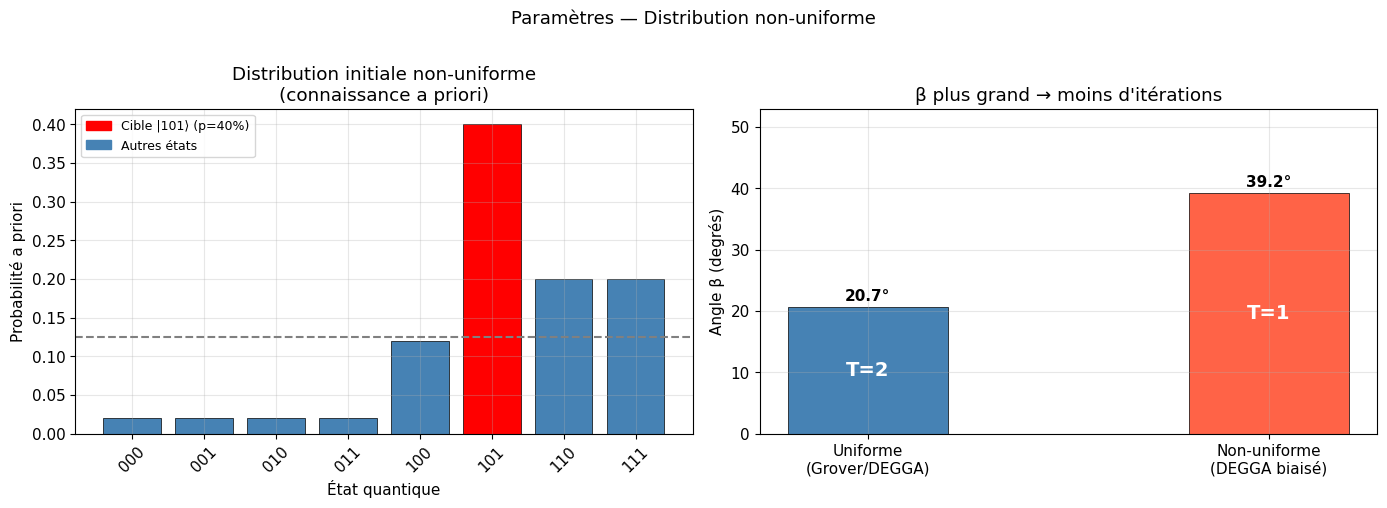

In [5]:
# =============================================================
# CELLULE 5 : ÉTAT INITIAL NON-UNIFORME ET PARAMÈTRES
# =============================================================

# ------------------------------------------------------------------
# Définition de la distribution a priori.
#
# Scénario : on sait que la solution est probablement dans la
# moitié supérieure de l'espace (états 4–7).
# Notre meilleure hypothèse est l'état 5, qui reçoit p=0.40.
#
# probs_init[i] = probabilité a priori que l'état |i⟩ soit la cible
# ------------------------------------------------------------------
probs_init = np.array([
    0.02,  # |000⟩ = 0  : zone peu probable
    0.02,  # |001⟩ = 1  : zone peu probable
    0.02,  # |010⟩ = 2  : zone peu probable
    0.02,  # |011⟩ = 3  : zone peu probable
    0.12,  # |100⟩ = 4  : possible
    0.40,  # |101⟩ = 5  ← état cible, forte probabilité a priori
    0.20,  # |110⟩ = 6  : probable
    0.20,  # |111⟩ = 7  : probable
])
probs_init = probs_init / probs_init.sum()   # normalisation

# Les amplitudes quantiques sont les racines carrées des probabilités
# (car |amplitude|² = probabilité de mesure)
amplitudes_init = np.sqrt(probs_init)

# β biaisé : arcsin de l'amplitude de l'état cible
beta_biaise = np.arcsin(amplitudes_init[CIBLE])
T_biaise, phi_biaise = parametres_long(beta_biaise)
P_biaise = prob_theorique(beta_biaise, phi_biaise, T_biaise)

print("Distribution a priori non-uniforme :")
for i, p in enumerate(probs_init):
    marqueur = " ← CIBLE" if i == CIBLE else ""
    print(f"  |{format(i, f'0{N_QUBITS}b')}⟩ = {i} : p = {p:.2f}{marqueur}")

print(f"\nComparaison des paramètres :")
print(f"{'Algorithme':<28} {'β':>8} {'β°':>8} {'T':>4} {'φ°':>8} {'P':>10}")
print("-" * 72)
print(f"{'Grover standard':<28} {beta_unif:>8.4f} {np.degrees(beta_unif):>7.2f}° {T_std:>4} {'180.0°':>8} {P_std:>10.4f}")
print(f"{'DEGGA (uniforme)':<28} {beta_unif:>8.4f} {np.degrees(beta_unif):>7.2f}° {T_long:>4} {np.degrees(phi_long):>7.2f}° {P_long:>10.6f}")
print(f"{'DEGGA biaisé':<28} {beta_biaise:>8.4f} {np.degrees(beta_biaise):>7.2f}° {T_biaise:>4} {np.degrees(phi_biaise):>7.2f}° {P_biaise:>10.6f}")
print(f"\n→ T réduit de {T_long} à {T_biaise} itération(s) grâce au biais !")

# --- Visualisation de la distribution et des β ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution a priori
etats = [format(i, f'0{N_QUBITS}b') for i in range(N)]
couleurs_dist = ['red' if i == CIBLE else 'steelblue' for i in range(N)]
ax1.bar(etats, probs_init, color=couleurs_dist, edgecolor='black', lw=0.5)
ax1.axhline(y=1/N, color='gray', linestyle='--', label=f'Uniforme = 1/{N} = {1/N:.3f}')
ax1.set_xlabel('État quantique')
ax1.set_ylabel('Probabilité a priori')
ax1.set_title('Distribution initiale non-uniforme\n(connaissance a priori)')
ax1.set_xticklabels(etats, rotation=45)
legende_d = [mpatches.Patch(color='red', label=f'Cible |{format(CIBLE,f"0{N_QUBITS}b")}⟩ (p={probs_init[CIBLE]:.0%})'),
             mpatches.Patch(color='steelblue', label='Autres états')]
ax1.legend(handles=legende_d, fontsize=9)

# Comparaison des β sous forme de barres
noms_beta = ['Uniforme\n(Grover/DEGGA)', 'Non-uniforme\n(DEGGA biaisé)']
betas_deg = [np.degrees(beta_unif), np.degrees(beta_biaise)]
T_vals    = [T_std, T_biaise]
couleurs_b = ['steelblue', 'tomato']
barres = ax2.bar(noms_beta, betas_deg, color=couleurs_b, edgecolor='black', lw=0.5, width=0.4)
for bar, val, T_val in zip(barres, betas_deg, T_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}°', ha='center', va='bottom', fontweight='bold')
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f'T={T_val}', ha='center', va='center', color='white', fontsize=14, fontweight='bold')
ax2.set_ylabel('Angle β (degrés)')
ax2.set_title('β plus grand → moins d\'itérations')
ax2.set_ylim(0, max(betas_deg) * 1.35)

plt.suptitle('Paramètres — Distribution non-uniforme', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# CELLULE 6 : DEGGA BIAISÉ — SIMULATION NUMPY
# =============================================================
# StatePreparation de Qiskit 2.x est trop lourd à simuler via
# Statevector ou AerSimulator (crash mémoire). On simule donc
# directement les opérateurs mathématiques en numpy, ce qui est
# équivalent et beaucoup plus léger.
#
# Rappel des opérateurs du DEGGA biaisé :
#
#   Oracle  Rτ(φ) : applique e^(iφ) à l'état cible
#     → En numpy : state[cible] *= exp(iφ)
#
#   Diffusion D_A(φ) = A · R₀(φ) · A†
#     = I + (e^(iφ)-1) |ψ₀⟩⟨ψ₀|
#     → En numpy : state += (exp(iφ)-1) * <ψ₀|state> * ψ₀
#
# Ces formules sont l'exacte traduction mathématique du circuit.
# =============================================================


def simuler_degga_biaise_numpy(amplitudes, cible, phi, T):
    """
    Simulation exacte du DEGGA biaisé (numpy pur, sans circuit Qiskit).

    L'algorithme applique T fois l'opérateur G = D_A(φ) · Rτ(φ) :

      1. Oracle Rτ(φ) :
         state[cible] *= e^(iφ)
         (multiplie l'amplitude de l'état cible par e^(iφ))

      2. Diffusion D_A(φ) = I + (e^(iφ)-1)|ψ₀⟩⟨ψ₀| :
         overlap = <ψ₀|state>   (produit scalaire)
         state  += (e^(iφ)-1) * overlap * ψ₀
         (amplifie la composante selon |ψ₀⟩)

    Paramètres
    ----------
    amplitudes : tableau numpy des amplitudes de |ψ₀⟩ (réelles, normalisé)
    cible      : indice de l'état cible
    phi        : angle de phase (condition de Long)
    T          : nombre d'itérations

    Retourne
    --------
    state : vecteur d'état final (complexe)
    """
    psi0  = amplitudes.astype(complex)  # état initial |ψ₀⟩
    state = psi0.copy()                  # état courant, commence à |ψ₀⟩

    phase = np.exp(1j * phi)             # précalcul de e^(iφ)

    for _ in range(T):
        # --- Oracle : phase sur l'état cible ---
        state[cible] *= phase

        # --- Diffusion D_A(φ) ---
        overlap = np.dot(psi0.conj(), state)   # ⟨ψ₀|state⟩
        state   = state + (phase - 1) * overlap * psi0

    return state


def probs_depuis_etat(state, n_qubits):
    """Convertit le vecteur d'état final en dictionnaire de probabilités."""
    probs = np.abs(state) ** 2
    return {format(i, f'0{n_qubits}b'): float(p) for i, p in enumerate(probs)}


def simuler_shots_numpy(probs_dict, shots=4096, seed=42):
    """
    Simule shots mesures quantiques par échantillonnage aléatoire.
    Équivalent à AerSimulator mais sans circuit — évite le crash.
    """
    np.random.seed(seed)
    etats  = list(probs_dict.keys())
    probas = np.array(list(probs_dict.values()))
    probas /= probas.sum()   # renormalisation numérique
    indices = np.random.choice(len(etats), size=shots, p=probas)
    counts = {}
    for idx in indices:
        e = etats[idx]
        counts[e] = counts.get(e, 0) + 1
    return counts


# --- Simulation exacte (numpy) ---
etat_final   = simuler_degga_biaise_numpy(amplitudes_init, CIBLE, phi_biaise, T_biaise)
probs_biaise = probs_depuis_etat(etat_final, N_QUBITS)

# --- Simulation par échantillonnage (numpy) ---
counts_biaise = simuler_shots_numpy(probs_biaise, shots=4096)

print(f"DEGGA biaisé : T={T_biaise} itération(s), φ={np.degrees(phi_biaise):.2f}°")
print(f"P(|{cle_cible}⟩) exacte = {probs_biaise[cle_cible]:.6f}  (théorie : {prob_theorique(beta_biaise, phi_biaise, T_biaise):.6f})")

# --- Visualisation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

afficher_barchart(
    ax1, probs_biaise, N_QUBITS, CIBLE,
    f'DEGGA Biaisé — Probabilités finales\n'
    f'T={T_biaise}, P(cible) = {probs_biaise[format(CIBLE, f"0{N_QUBITS}b")]:.4f}',
    'tomato'
)
# Superposer la distribution initiale en pointillés
etats_plot = [format(i, f'0{N_QUBITS}b') for i in range(N)]
ax1.bar(etats_plot, probs_init, color='none', edgecolor='black', linestyle='--',
        linewidth=1.5, label='Distribution initiale', zorder=5)
ax1.legend(fontsize=9)

# Évolution des probabilités pour les 3 algorithmes
max_j = max(T_std, T_long, T_biaise) + 3
jters = list(range(max_j + 1))
p_std_evo3   = [prob_theorique(beta_unif,   np.pi,      j) for j in jters]
p_long_evo3  = [prob_theorique(beta_unif,   phi_long,   j) for j in jters]
p_biais_evo3 = [prob_theorique(beta_biaise, phi_biaise, j) for j in jters]

ax2.plot(jters, p_std_evo3,   'o-',  color='steelblue',  lw=2, label=f'Grover std (φ=180°, T={T_std})')
ax2.plot(jters, p_long_evo3,  's--', color='darkorange', lw=2, label=f'DEGGA unif (φ={np.degrees(phi_long):.0f}°, T={T_long})')
ax2.plot(jters, p_biais_evo3, '^-',  color='tomato',     lw=2.5, label=f'DEGGA biaisé (φ={np.degrees(phi_biaise):.0f}°, T={T_biaise})')
ax2.axhline(y=1.0, color='gray', linestyle=':', alpha=0.6)
ax2.scatter([T_biaise], [p_biais_evo3[T_biaise]], color='tomato', s=200, zorder=5, marker='*')
ax2.set_xlabel("Nombre d'itérations j")
ax2.set_ylabel('P(succès)')
ax2.set_title("DEGGA biaisé converge en moins d'itérations !")
ax2.legend(fontsize=9)
ax2.set_ylim(-0.05, 1.25)

plt.suptitle('DEGGA Biaisé — État Initial Non-Uniforme', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

freq_b = counts_biaise.get(cle_cible, 0) / sum(counts_biaise.values())
print(f"\nSimulation (4096 shots) : fréquence |{cle_cible}⟩ = {freq_b:.3f}")
print(f"Probabilité théorique   : {probs_biaise[cle_cible]:.6f}")


In [ ]:
# =============================================================
# CELLULE 7 : ANALYSE — IMPACT DU BIAIS SUR LE NOMBRE D'ITÉRATIONS
# =============================================================
# Que se passe-t-il quand on fait varier la probabilité a priori
# de l'état cible dans la distribution initiale ?
# =============================================================

print("Analyse : T en fonction de la probabilité a priori p_cible")
print("=" * 60)

# Plage de probabilités a priori pour l'état cible
p_cibles = np.linspace(0.01, 0.99, 500)

T_vals_analyse   = []
phi_vals_analyse = []
for p in p_cibles:
    b = np.arcsin(np.sqrt(p))
    T_val, phi_val = parametres_long(b)
    T_vals_analyse.append(T_val)
    phi_vals_analyse.append(np.degrees(phi_val))

# Points de référence
p_unif_ref = 1.0 / N
p_biais_ref = probs_init[CIBLE]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# T en fonction de p_cible
ax1.step(p_cibles, T_vals_analyse, color='navy', linewidth=2)
ax1.axvline(x=p_unif_ref, color='steelblue', linestyle='--', lw=2,
            label=f'Uniforme p=1/{N}={p_unif_ref:.3f} → T={T_std}')
ax1.axvline(x=p_biais_ref, color='tomato', linestyle='--', lw=2,
            label=f'Biaisé p={p_biais_ref:.2f} → T={T_biaise}')
ax1.scatter([p_unif_ref], [T_std],   color='steelblue', s=100, zorder=5)
ax1.scatter([p_biais_ref], [T_biaise], color='tomato',  s=100, zorder=5)
ax1.set_xlabel('Probabilité a priori de la cible $p_{\\tau}$')
ax1.set_ylabel('Nombre d\'itérations T')
ax1.set_title('Réduction des itérations avec le biais')
ax1.legend(fontsize=9)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, max(T_vals_analyse) + 1)

# φ en fonction de p_cible
ax2.plot(p_cibles, phi_vals_analyse, color='navy', linewidth=2)
ax2.axhline(y=180, color='gray', linestyle=':', alpha=0.7, label='φ = 180° (Grover std)')
ax2.axvline(x=p_unif_ref, color='steelblue', linestyle='--', lw=2,
            label=f'Uniforme p={p_unif_ref:.3f}')
ax2.axvline(x=p_biais_ref, color='tomato', linestyle='--', lw=2,
            label=f'Biaisé p={p_biais_ref:.2f}')
ax2.set_xlabel('Probabilité a priori de la cible $p_{\\tau}$')
ax2.set_ylabel('Angle de phase φ (degrés)')
ax2.set_title('Phase optimale φ selon le biais')
ax2.legend(fontsize=9)
ax2.set_xlim(0, 1)

plt.suptitle(f'Impact du biais sur les paramètres DEGGA (N={N} états)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('analyse_biais_DEGGA.png', dpi=150, bbox_inches='tight')
plt.show()

# Tableau de quelques valeurs caractéristiques
print(f"\n{'p_cible':>10} {'β (°)':>8} {'T':>4} {'φ (°)':>8}")
print("-" * 35)
for p_test in [1/N, 0.20, 0.30, 0.40, 0.50, 0.75]:
    b_test = np.arcsin(np.sqrt(p_test))
    T_test, phi_test = parametres_long(b_test)
    marqueur = " ← uniforme" if abs(p_test - 1/N) < 0.001 else (" ← biaisé" if abs(p_test - p_biais_ref) < 0.01 else "")
    print(f"{p_test:>10.3f} {np.degrees(b_test):>8.2f} {T_test:>4} {np.degrees(phi_test):>8.2f}{marqueur}")

In [ ]:
# =============================================================
# CELLULE 8 : COMPARAISON FINALE — LES 3 ALGORITHMES
# =============================================================

print("COMPARAISON FINALE")
print("=" * 65)
print(f"{'Algorithme':<26} {'β':>8} {'T':>4} {'φ':>8}  {'P théorique':>12}  {'Shots'}")
print("-" * 75)

resultats = [
    ("Grover standard",   probs_std,    counts_std,    beta_unif,   T_std,    np.pi,      P_std,    'steelblue'),
    ("DEGGA (uniforme)",  probs_long,   counts_long,   beta_unif,   T_long,   phi_long,   P_long,   'darkorange'),
    ("DEGGA biaisé",      probs_biaise, counts_biaise, beta_biaise, T_biaise, phi_biaise, P_biaise, 'tomato'),
]

for nom, p_dict, cnts, beta, T, phi, P_th, _ in resultats:
    freq = cnts.get(cle_cible, 0) / sum(cnts.values())
    print(f"{nom:<26} {np.degrees(beta):>7.2f}° {T:>4} {np.degrees(phi):>7.2f}°  {P_th:>12.6f}  {freq:.3f}")

print(f"\n(État cible : |{cle_cible}⟩ = {CIBLE}, N = {N} états)")

# --- Graphique de comparaison final ---
fig = plt.figure(figsize=(18, 5))
gspec = GridSpec(1, 4, figure=fig, wspace=0.4)

# Un histogramme par algorithme
for col_idx, (nom, p_dict, cnts, beta, T, phi, P_th, coul) in enumerate(resultats):
    ax = fig.add_subplot(gspec[0, col_idx])
    afficher_barchart(
        ax, p_dict, N_QUBITS, CIBLE,
        f'{nom}\nT={T}, φ={np.degrees(phi):.0f}°\nP={P_th:.4f}',
        coul
    )

# Graphique comparatif des courbes de convergence
ax_conv = fig.add_subplot(gspec[0, 3])
max_j_final = max(T_std, T_long, T_biaise) + 3
jj = list(range(max_j_final + 1))
for nom, p_dict, cnts, beta, T, phi, P_th, coul in resultats:
    p_evo = [prob_theorique(beta, phi, j) for j in jj]
    sym = 'o-' if coul == 'steelblue' else ('s--' if coul == 'darkorange' else '^-')
    ax_conv.plot(jj, p_evo, sym, color=coul, lw=2, markersize=6, label=nom.split(' ')[0] + ('+' if 'Biaisé' in nom else ''))
    ax_conv.scatter([T], [p_evo[T]], s=150, color=coul, zorder=5, marker='*')
ax_conv.axhline(y=1.0, color='gray', linestyle=':', alpha=0.6)
ax_conv.set_xlabel("Itérations j")
ax_conv.set_ylabel('P(succès)')
ax_conv.set_title('Convergence comparée')
ax_conv.legend(fontsize=9)
ax_conv.set_ylim(-0.05, 1.25)

plt.suptitle(f'Comparaison Finale — N={N} états, cible=|{cle_cible}⟩={CIBLE}',
             fontsize=13, y=1.02)
plt.savefig('comparaison_finale_DEGGA.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Bilan ---
print("\n" + "=" * 65)
print("BILAN")
print("=" * 65)
print(f"  1. Grover standard : T={T_std}, P≈{P_std:.2%} (pas exactement 100%)")
print(f"  2. DEGGA uniforme  : T={T_long}, P={P_long:.2%} EXACT — même nombre d'itérations")
print(f"  3. DEGGA biaisé    : T={T_biaise}, P={P_biaise:.2%} EXACT — {T_long - T_biaise} itération(s) économisée(s)")
print()
print(f"  Le biais (p_cible={probs_init[CIBLE]:.0%} vs 1/N={1/N:.1%}) réduit T de {T_long} à {T_biaise}.")
print(f"  Clé : adapter la diffusion D_A = A·R₀(φ)·A† à l'état initial biaisé.")